# Modelo de Machine Learning para estimación de precios de alojamiento en CulturaTrip

Este notebook presenta el desarrollo del modelo de regresión utilizado para estimar el coste del alojamiento dentro del prototipo analítico de CulturaTrip. El objetivo es predecir el precio esperado del hospedaje a partir de variables turísticas y contextuales, con el fin de incorporarlo al flujo de planificación inteligente del viaje.

## Objetivo del modelo

El objetivo de este modelo es estimar el precio del alojamiento turístico a partir de variables geográficas, temporales y de características del hospedaje. Esta predicción permite calcular de forma más realista el coste del alojamiento dentro del viaje y compararlo con el presupuesto disponible asignado a esta categoría.

En el contexto del proyecto CulturaTrip, el modelo no se utiliza como un ejercicio aislado de predicción, sino como un componente funcional dentro del simulador de presupuesto y del prototipo desarrollado en Streamlit.

## Preparación del entorno y definición de rutas

Se definen las rutas base del proyecto para garantizar la correcta lectura y escritura de archivos del pipeline de Machine Learning.

In [1]:
import os
import ast
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


BASE_DIR = Path.cwd().resolve().parents[1]

OUTPUTS_DIR = BASE_DIR / "outputs" / "regresion_precios"
MODEL_DIR = OUTPUTS_DIR / "modelos"
ML_DIR = BASE_DIR / "data" / "Machine Learning"

input_largo = ML_DIR / "df_precios_largo.csv"
input_features = ML_DIR / "df_precios_features.csv"

metricas_path = ML_DIR / "metricas_modelos_regresion.csv"
metricas_rf_path = ML_DIR / "metricas_random_forest_optimizado.csv"

model_path = MODEL_DIR / "random_forest_precio.pkl"
features_path = MODEL_DIR / "features_modelo_precio.pkl"

print("ML_DIR:", ML_DIR)
print("MODEL_DIR:", MODEL_DIR)


ML_DIR: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning
MODEL_DIR: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos


In [4]:
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    # Si estás en notebook o entorno interactivo
    BASE_DIR = Path(os.getcwd())

BASE_DIR = Path(r"C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM")
ASSETS_DIR = BASE_DIR / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)

## 1.Preparación del dataset

La fase inicial consistió en transformar el dataset de alojamientos desde un formato ancho a un formato largo. Esta transformación fue necesaria para representar en una sola variable objetivo el precio del alojamiento, diferenciando explícitamente entre precios de noches entre semana y noches de fin de semana.

Cada registro resultante representa una observación de precio asociada a un tipo de día específico, lo que permite al modelo aprender patrones diferenciados según el comportamiento del mercado turístico.

El modelo parte del archivo `df_alojamientos.csv`, el cual contiene información agregada de alojamientos turísticos en España. Entre sus variables se incluyen identificadores geográficos, mes, categoría de alojamiento, periodo de antelación, valoraciones y precios diferenciados para check-in entre semana y fin de semana.

### Integración de datos
En esta fase no se realiza una integración múltiple de fuentes dentro del notebook, sino que se parte de un dataset ya consolidado dentro del pipeline del proyecto. La principal transformación consiste en convertir las columnas de precio entre semana y fin de semana a un formato largo, con el fin de que el modelo pueda aprender explícitamente el efecto del tipo de día sobre el precio.

In [5]:
input_path = BASE_DIR / "data" / "clean" / "df_alojamientos.csv"
output_path = ML_DIR / "df_precios_largo.csv"

df = pd.read_csv(input_path)

print("Dimensiones originales:", df.shape)
df.head()

Dimensiones originales: (10280, 15)


,id_alojamiento,id_pais,id_ccaa,id_provincia,mes,categoria_alojamiento,periodo_antelacion,precio_checkin_entre_semana,precio_checkin_fin_semana,tiene_valoraciones,fuente,granularidad_origen,es_dato_replicado,nivel_geografico,valoraciones_norm
0,1,ES,1,4,1,hotel 3 estrellas,1 mes,70.0000,72.0000,True,hotel_dataestur,provincia,False,provincia,3.7595
1,2,ES,1,4,1,hotel 3 estrellas,1 semana,71.0000,73.6700,True,hotel_dataestur,provincia,False,provincia,3.7595
2,3,ES,1,4,1,hotel 3 estrellas,2 semanas,71.0000,73.6700,True,hotel_dataestur,provincia,False,provincia,3.7595
3,4,ES,1,4,1,hotel 3 estrellas,3 meses,67.3300,70.3300,True,hotel_dataestur,provincia,False,provincia,3.7595
4,5,ES,1,4,1,hotel 4 estrellas,1 mes,75.3300,78.6700,True,hotel_dataestur,provincia,False,provincia,3.2400


### Limpieza de datos
Antes de transformar el dataset, se revisa su estructura general, tipos de datos y consistencia básica, con el propósito de identificar posibles incidencias que puedan afectar el entrenamiento del modelo.

In [6]:
print("Tipos de datos:")
display(df.dtypes)

print("\nResumen general:")
display(df.describe(include="all").T)

Tipos de datos:


id_alojamiento                   int64
id_pais                         object
id_ccaa                          int64
id_provincia                     int64
mes                              int64
categoria_alojamiento           object
periodo_antelacion              object
precio_checkin_entre_semana    float64
precio_checkin_fin_semana      float64
tiene_valoraciones                bool
fuente                          object
granularidad_origen             object
es_dato_replicado                 bool
nivel_geografico                object
valoraciones_norm              float64
dtype: object


Resumen general:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_alojamiento,"10,280.0000",NaN,NaN,NaN,"5,140.5000","2,967.7247",1.0000,"2,570.7500","5,140.5000","7,710.2500","10,280.0000"
id_pais,10280,1,ES,10280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_ccaa,"10,280.0000",NaN,NaN,NaN,7.7456,4.6604,1.0000,4.0000,8.0000,11.0000,19.0000
id_provincia,"10,280.0000",NaN,NaN,NaN,25.7153,14.5679,1.0000,13.0000,26.0000,38.0000,52.0000
mes,"10,280.0000",NaN,NaN,NaN,6.5017,3.4519,1.0000,4.0000,7.0000,10.0000,12.0000
categoria_alojamiento,10280,8,hotel 3 estrellas,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN
periodo_antelacion,10280,5,1 mes,3852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio_checkin_entre_semana,"10,280.0000",NaN,NaN,NaN,145.2025,94.8771,22.6300,85.6700,118.7500,178.6700,"1,753.3700"
precio_checkin_fin_semana,"10,280.0000",NaN,NaN,NaN,161.4917,99.5127,22.6300,98.3300,133.6800,200.1700,"1,753.3700"
tiene_valoraciones,10280,1,True,10280,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Validación de datos
Se realiza una validación inicial para detectar:
- valores nulos,
- registros duplicados,
- posibles valores atípicos en las variables numéricas de precio.

Esta revisión permite documentar la calidad del dataset previo al modelado.

In [7]:
print("=== NULOS POR COLUMNA ===")
display(df.isnull().sum().to_frame("nulos"))

print("=== DUPLICADOS EXACTOS ===")
duplicados = df.duplicated().sum()
print("Total duplicados exactos:", duplicados)

=== NULOS POR COLUMNA ===


,nulos
id_alojamiento,0
id_pais,0
id_ccaa,0
id_provincia,0
mes,0
categoria_alojamiento,0
periodo_antelacion,0
precio_checkin_entre_semana,0
precio_checkin_fin_semana,0
tiene_valoraciones,0


=== DUPLICADOS EXACTOS ===
Total duplicados exactos: 0


In [8]:
columnas_precio = [
    "precio_checkin_entre_semana",
    "precio_checkin_fin_semana"
]

print("=== DESCRIPTIVOS DE VARIABLES DE PRECIO ===")
display(df[columnas_precio].describe().T)

=== DESCRIPTIVOS DE VARIABLES DE PRECIO ===


,count,mean,std,min,25%,50%,75%,max
precio_checkin_entre_semana,"10,280.0000",145.2025,94.8771,22.6300,85.6700,118.7500,178.6700,"1,753.3700"
precio_checkin_fin_semana,"10,280.0000",161.4917,99.5127,22.6300,98.3300,133.6800,200.1700,"1,753.3700"


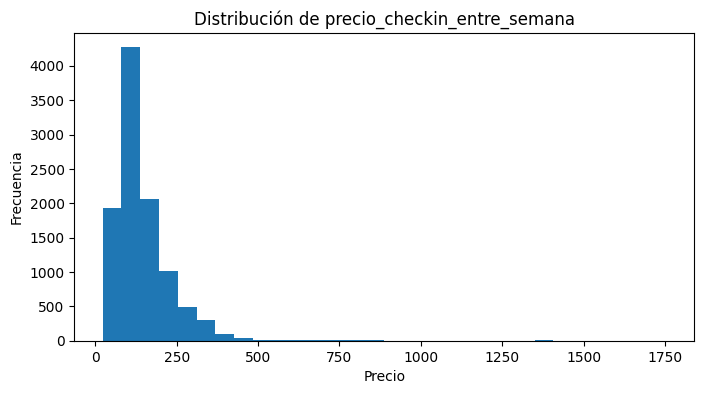

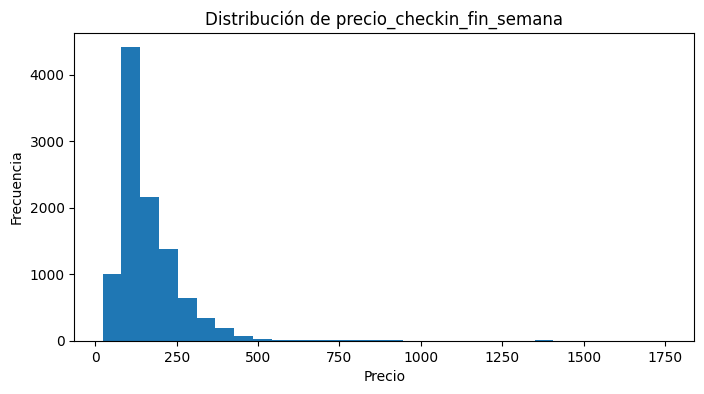

In [9]:
for col in columnas_precio:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel("Precio")
    plt.ylabel("Frecuencia")
    plt.show()

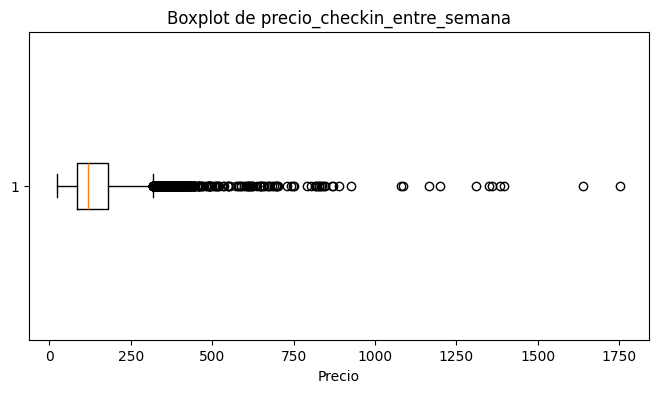

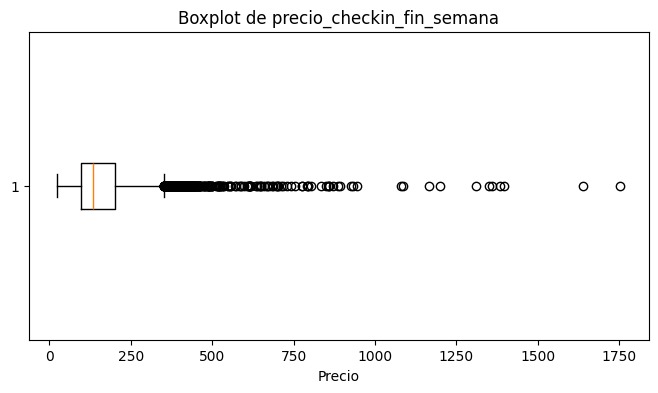

In [10]:
for col in columnas_precio:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel("Precio")
    plt.show()

In [30]:
# ============================================
# Detección de outliers por metodo IQR
# ============================================
def detectar_outliers_iqr(df, columnas):
    resumen = []

    for col in columnas:
        serie = df[col].dropna()

        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        mask_outliers = (df[col] < limite_inferior) | (df[col] > limite_superior)
        total_outliers = mask_outliers.sum()

        porcentaje = (total_outliers / len(df)) * 100

        resumen.append({
            "variable": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "limite_inferior": limite_inferior,
            "limite_superior": limite_superior,
            "total_outliers": int(total_outliers),
            "porcentaje_outliers (%)": round(porcentaje, 2)
        })

    return pd.DataFrame(resumen)

In [31]:
columnas_precio = [
    "precio_checkin_entre_semana",
    "precio_checkin_fin_semana"
]

resumen_outliers = detectar_outliers_iqr(df, columnas_precio)
display(resumen_outliers)

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,total_outliers,porcentaje_outliers (%)
0,precio_checkin_entre_semana,85.6700,178.6700,93.0000,-53.8300,318.1700,483,4.7000
1,precio_checkin_fin_semana,98.3300,200.1700,101.8400,-54.4300,352.9300,447,4.3500


In [37]:
for _, fila in resumen_outliers.iterrows():
    print(
        f"{fila['variable']} → "
        f"{fila['total_outliers']} outliers "
        f"({fila['porcentaje_outliers (%)']}%)"
    )

precio_checkin_entre_semana → 483 outliers (4.7%)
precio_checkin_fin_semana → 447 outliers (4.35%)


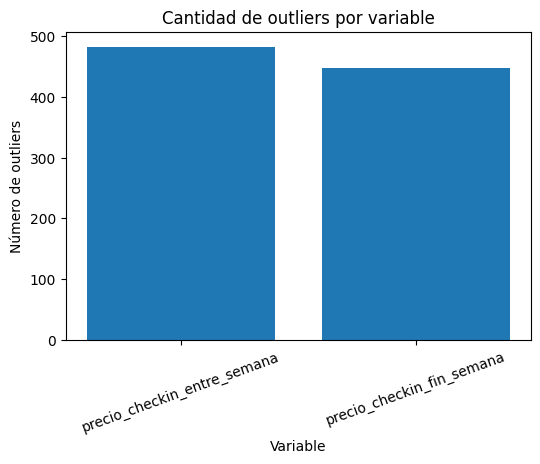

In [38]:
plt.figure(figsize=(6,4))
plt.bar(
    resumen_outliers["variable"],
    resumen_outliers["total_outliers"]
)
plt.title("Cantidad de outliers por variable")
plt.xlabel("Variable")
plt.ylabel("Número de outliers")
plt.xticks(rotation=20)
plt.show()

In [35]:
for col in columnas_precio:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers_df = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"\n=== Outliers detectados en {col} ===")
    print(f"Total: {outliers_df.shape[0]}")
    display(outliers_df[[col]].head(10))


=== Outliers detectados en precio_checkin_entre_semana ===
Total: 483


,precio_checkin_entre_semana
238,321.0000
908,357.3300
909,356.6700
910,357.0000
911,345.0000
920,379.6700
921,384.0000
922,363.3300
923,375.0000
932,353.0000



=== Outliers detectados en precio_checkin_fin_semana ===
Total: 447


,precio_checkin_fin_semana
347,399.0000
908,406.0000
909,392.0000
910,402.3300
911,381.0000
920,423.3300
921,402.0000
922,391.3300
923,397.3300
932,413.0000


In [39]:
df[df["precio_checkin_fin_semana"] > 300][
    ["categoria_alojamiento", "precio_checkin_fin_semana"]
].value_counts().head(10)

categoria_alojamiento  precio_checkin_fin_semana
alternativo            339.7000                     16
                       333.7600                      8
                       353.1700                      8
                       353.0000                      8
                       331.9800                      8
hotel 5 estrellas      307.3300                      7
                       363.0000                      6
                       315.0000                      5
                       329.0000                      5
                       311.6700                      5
Name: count, dtype: int64

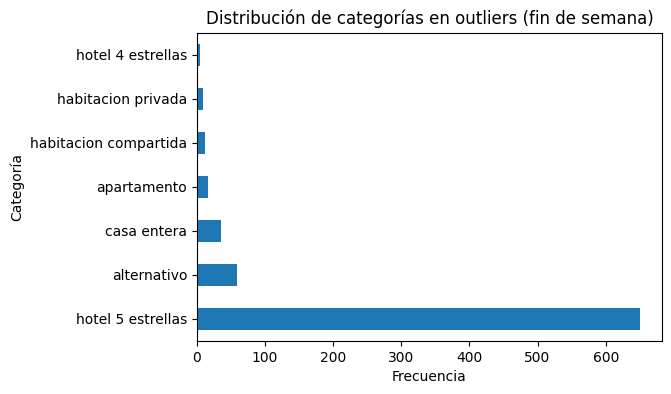

In [46]:
df_outliers = df[df["precio_checkin_fin_semana"] > 300]

conteo = df_outliers["categoria_alojamiento"].value_counts()

plt.figure(figsize=(6,4))
conteo.plot(kind="barh")
plt.title("Distribución de categorías en outliers (fin de semana)")
plt.xlabel("Frecuencia")
plt.ylabel("Categoría")
plt.show()

In [47]:
conteo_pct = df_outliers["categoria_alojamiento"].value_counts(normalize=True) * 100

display(conteo_pct)

categoria_alojamiento
hotel 5 estrellas       82.4873
alternativo              7.4873
casa entera              4.5685
apartamento              2.1574
habitacion compartida    1.5228
habitacion privada       1.1421
hotel 4 estrellas        0.6345
Name: proportion, dtype: float64

Para validar la naturaleza de los valores atípicos identificados, se realizó un análisis adicional considerando las categorías de alojamiento asociadas a los precios más elevados.

Los resultados muestran que una proporción significativa de estos valores corresponde a alojamientos clasificados como "hotel 5 estrellas", lo cual confirma que dichos valores representan el segmento de alta gama del mercado turístico.

Asimismo, se identificaron valores elevados en la categoría "alternativo", lo cual sugiere la presencia de alojamientos no tradicionales de alto valor, tales como villas, apartamentos de lujo o experiencias boutique.

Estos hallazgos permiten concluir que los outliers detectados no corresponden a errores en los datos, sino a comportamientos reales del mercado, asociados a segmentos premium y experiencias diferenciadas.

En consecuencia, se decide no eliminar estos valores, con el fin de preservar la representatividad del dataset y permitir que el modelo capture la variabilidad real del precio en el sector turístico.

### Detección de outliers

Se realizó la identificación de valores atípicos mediante el método del rango intercuartílico (IQR).

Los resultados muestran que ambas variables de precio presentan un porcentaje reducido de outliers (inferior al 5%), lo cual es consistente con datasets de precios turísticos, donde es común observar valores extremos asociados a alojamientos de lujo o ubicaciones premium.

Adicionalmente, se observa que los límites inferiores calculados por el método IQR son negativos, lo cual no tiene interpretación real en el contexto del problema. Esto se debe a la dispersión de los datos y no implica errores en el dataset.

Dado el bajo impacto relativo de los outliers, su tratamiento será evaluado cuidadosamente para evitar la pérdida de información relevante en el modelo.

Estos valores elevados pueden estar asociados principalmente a alojamientos de gama alta, ubicaciones premium o condiciones específicas de alta demanda, como temporadas altas o eventos.

No obstante, también es posible que una pequeña proporción de estos valores corresponda a inconsistencias o variabilidad extrema del mercado, por lo que su interpretación debe realizarse con cautela.

Dado que estos valores reflejan comportamientos reales del mercado y no únicamente errores, se opta por no eliminarlos, permitiendo que el modelo capture adecuadamente la heterogeneidad del precio en el sector turístico.

### Tratamiento de outliers

Tras la detección de valores atípicos mediante el método del rango intercuartílico (IQR), se observó que estos representan aproximadamente entre un 4% y 5% del total de los datos.

Un análisis adicional permitió identificar que estos valores corresponden principalmente a alojamientos de gama alta, como hoteles de 5 estrellas y alojamientos alternativos de lujo.

Dado que estos valores reflejan comportamientos reales del mercado y no errores en los datos, se decidió no aplicar técnicas de tratamiento como eliminación o capping, con el fin de preservar la variabilidad real del precio.

### Transformación del dataset a formato largo
Con el fin de modelar correctamente la diferencia entre precios de check-in entre semana y fin de semana, se convierten ambas columnas en una única variable objetivo denominada `precio`, acompañada de una variable categórica `tipo_dia`.

In [49]:
df_largo = df.melt(
    id_vars=[
        "id_alojamiento",
        "id_pais",
        "id_ccaa",
        "id_provincia",
        "mes",
        "categoria_alojamiento",
        "periodo_antelacion",
        "tiene_valoraciones",
        "fuente",
        "granularidad_origen",
        "es_dato_replicado",
        "nivel_geografico",
        "valoraciones_norm"
    ],
    value_vars=[
        "precio_checkin_entre_semana",
        "precio_checkin_fin_semana"
    ],
    var_name="tipo_dia_original",
    value_name="precio"
)

map_tipo_dia = {
    "precio_checkin_entre_semana": "semana",
    "precio_checkin_fin_semana": "fin_semana"
}

df_largo["tipo_dia"] = df_largo["tipo_dia_original"].map(map_tipo_dia)

columnas_finales = [
    "id_alojamiento",
    "id_pais",
    "id_ccaa",
    "id_provincia",
    "mes",
    "categoria_alojamiento",
    "periodo_antelacion",
    "valoraciones_norm",
    "tiene_valoraciones",
    "tipo_dia",
    "precio"
]

df_largo = df_largo[columnas_finales].copy()
df_largo.to_csv(output_path, index=False, encoding="utf-8")

print("Dimensiones formato largo:", df_largo.shape)
display(df_largo.head())
display(df_largo["tipo_dia"].value_counts())

Dimensiones formato largo: (20560, 11)


,id_alojamiento,id_pais,id_ccaa,id_provincia,mes,categoria_alojamiento,periodo_antelacion,valoraciones_norm,tiene_valoraciones,tipo_dia,precio
0,1,ES,1,4,1,hotel 3 estrellas,1 mes,3.7595,True,semana,70.0000
1,2,ES,1,4,1,hotel 3 estrellas,1 semana,3.7595,True,semana,71.0000
2,3,ES,1,4,1,hotel 3 estrellas,2 semanas,3.7595,True,semana,71.0000
3,4,ES,1,4,1,hotel 3 estrellas,3 meses,3.7595,True,semana,67.3300
4,5,ES,1,4,1,hotel 4 estrellas,1 mes,3.2400,True,semana,75.3300


tipo_dia
semana        10280
fin_semana    10280
Name: count, dtype: int64

## Feature engineering

Posteriormente se realizó una etapa de ingeniería de variables con el fin de preparar una base adecuada para el entrenamiento del modelo. En esta fase se construyeron y codificaron variables relevantes para la predicción del precio del alojamiento, entre ellas:

- mes del viaje
- temporada
- categoría del alojamiento
- periodo de antelación de la reserva
- presencia de valoraciones
- nivel de valoraciones
- tipo de día

Estas transformaciones permitieron convertir variables categóricas en variables numéricas interpretables por los algoritmos de regresión y, al mismo tiempo, reflejar mejor la dinámica del precio turístico.

In [50]:
output_features_path = ML_DIR / "df_precios_features.csv"

df = df_largo.copy()

def clasificar_temporada(mes):
    if mes in [12, 1, 2]:
        return "baja"
    elif mes in [3, 4, 5, 10, 11]:
        return "media"
    elif mes in [6, 7, 8, 9]:
        return "alta"
    else:
        return "desconocida"

df["temporada"] = df["mes"].apply(clasificar_temporada)

map_tipo_dia = {"semana": 0, "fin_semana": 1}
df["tipo_dia_cod"] = df["tipo_dia"].map(map_tipo_dia)

map_categoria = {
    "hotel 3 estrellas": 1,
    "hotel 4 estrellas": 2,
    "hotel 5 estrellas": 3,
    "apartamento": 4,
    "casa entera": 5,
    "habitacion privada": 6,
    "habitacion compartida": 7,
    "alternativo": 8
}
df["categoria_alojamiento_cod"] = df["categoria_alojamiento"].map(map_categoria)

map_antelacion = {
    "1 semana": 1,
    "2 semanas": 2,
    "1 mes": 3,
    "2-3 meses": 4,
    "3 meses": 5
}
df["periodo_antelacion_cod"] = df["periodo_antelacion"].map(map_antelacion)

map_temporada = {"baja": 1, "media": 2, "alta": 3}
df["temporada_cod"] = df["temporada"].map(map_temporada)

df["es_fin_de_semana"] = df["tipo_dia_cod"]

columnas_finales = [
    "id_alojamiento",
    "id_pais",
    "id_ccaa",
    "id_provincia",
    "mes",
    "temporada",
    "temporada_cod",
    "categoria_alojamiento",
    "categoria_alojamiento_cod",
    "periodo_antelacion",
    "periodo_antelacion_cod",
    "valoraciones_norm",
    "tiene_valoraciones",
    "tipo_dia",
    "tipo_dia_cod",
    "es_fin_de_semana",
    "precio"
]

df = df[columnas_finales].copy()
df.to_csv(output_features_path, index=False, encoding="utf-8")

print("Dimensiones dataset features:", df.shape)
display(df.head())
display(df.isnull().sum())

Dimensiones dataset features: (20560, 17)


,id_alojamiento,id_pais,id_ccaa,id_provincia,mes,temporada,temporada_cod,categoria_alojamiento,categoria_alojamiento_cod,periodo_antelacion,periodo_antelacion_cod,valoraciones_norm,tiene_valoraciones,tipo_dia,tipo_dia_cod,es_fin_de_semana,precio
0,1,ES,1,4,1,baja,1,hotel 3 estrellas,1,1 mes,3,3.7595,True,semana,0,0,70.0000
1,2,ES,1,4,1,baja,1,hotel 3 estrellas,1,1 semana,1,3.7595,True,semana,0,0,71.0000
2,3,ES,1,4,1,baja,1,hotel 3 estrellas,1,2 semanas,2,3.7595,True,semana,0,0,71.0000
3,4,ES,1,4,1,baja,1,hotel 3 estrellas,1,3 meses,5,3.7595,True,semana,0,0,67.3300
4,5,ES,1,4,1,baja,1,hotel 4 estrellas,2,1 mes,3,3.2400,True,semana,0,0,75.3300


id_alojamiento               0
id_pais                      0
id_ccaa                      0
id_provincia                 0
mes                          0
temporada                    0
temporada_cod                0
categoria_alojamiento        0
categoria_alojamiento_cod    0
periodo_antelacion           0
periodo_antelacion_cod       0
valoraciones_norm            0
tiene_valoraciones           0
tipo_dia                     0
tipo_dia_cod                 0
es_fin_de_semana             0
precio                       0
dtype: int64

### Resumen de Feature Engineering
#### 1. Creación de la variable temporada

A partir de la variable mes, se construyó una nueva variable categórica llamada temporada, con el fin de representar la estacionalidad del turismo.

La clasificación aplicada fue la siguiente:

baja: diciembre, enero y febrero

media: marzo, abril, mayo, octubre y noviembre

alta: junio, julio, agosto y septiembre

La lógica utilizada responde a una simplificación operativa del comportamiento estacional del turismo, permitiendo agrupar los meses en bloques interpretables para el modelo.

#### 2. Codificación de tipo_dia

La variable tipo_dia, originada en la transformación a formato largo, distingue entre:

semana

fin_semana

Para que esta información pudiera ser utilizada por el modelo, se realizó una codificación binaria:

semana = 0

fin_semana = 1

Esta transformación facilita el uso de la variable dentro de algoritmos supervisados y permite capturar el efecto diferencial del fin de semana sobre el precio.

#### 3. Codificación de la categoría de alojamiento

La variable categoria_alojamiento fue transformada a formato numérico mediante un diccionario de mapeo. La codificación aplicada fue:

hotel 3 estrellas = 1

hotel 4 estrellas = 2

hotel 5 estrellas = 3

apartamento = 4

casa entera = 5

habitacion privada = 6

habitacion compartida = 7

alternativo = 8

Esta codificación permite que el modelo procese una variable originalmente textual. Aunque los valores asignados no implican por sí mismos una relación lineal estricta, sí constituyen una forma práctica de representar categorías en esta primera versión del modelo.

#### 4. Codificación del periodo de antelación

La variable periodo_antelacion también fue transformada a formato numérico, con el propósito de representar la anticipación de la reserva como una característica predictiva.

La codificación utilizada fue:

1 semana = 1

2 semanas = 2

1 mes = 3

2-3 meses = 4

3 meses = 5

Esta variable busca capturar el posible efecto que tiene la antelación de compra sobre el precio del alojamiento.

#### 5. Codificación numérica de la temporada

Además de la variable categórica temporada, se generó una versión codificada denominada temporada_cod, asignando:

baja = 1

media = 2

alta = 3

La finalidad de esta variable es permitir que la estacionalidad sea incorporada directamente en el modelo de regresión.

#### 6. Creación del indicador es_fin_de_semana

Se creó una variable adicional llamada es_fin_de_semana, definida como una copia directa de tipo_dia_cod.

df["es_fin_de_semana"] = df["tipo_dia_cod"]

Esta variable actúa como un indicador explícito del tipo de día, reforzando la interpretación del efecto fin de semana dentro del dataset. En términos prácticos, representa la misma información que tipo_dia_cod, pero con una denominación más interpretable desde el punto de vista analítico.


## Análisis descriptivo del feature engineering

Se examina la distribución de las variables generadas para verificar su consistencia y comprender el comportamiento general del dataset de entrenamiento.

In [51]:
print("=== NULOS EN DATASET FINAL ===")
display(df.isnull().sum().to_frame("nulos"))

print("=== VARIABLES CATEGÓRICAS CODIFICADAS ===")
display(df[[
    "temporada",
    "categoria_alojamiento",
    "periodo_antelacion",
    "tipo_dia"
]].describe(include="all").T)

=== NULOS EN DATASET FINAL ===


,nulos
id_alojamiento,0
id_pais,0
id_ccaa,0
id_provincia,0
mes,0
temporada,0
temporada_cod,0
categoria_alojamiento,0
categoria_alojamiento_cod,0
periodo_antelacion,0


=== VARIABLES CATEGÓRICAS CODIFICADAS ===


,count,unique,top,freq
temporada,20560,3,media,8566
categoria_alojamiento,20560,8,hotel 3 estrellas,4800
periodo_antelacion,20560,5,1 mes,7704
tipo_dia,20560,2,semana,10280


Insight

temporada: 3 categorías → balanceado

categoría: 8 → diversidad alta

antelación: 5 → buena granularidad

tipo_dia: 2 → balance perfecto

Interpretación

Buen diseño de features:

ni demasiado simple

ni excesivamente complejo

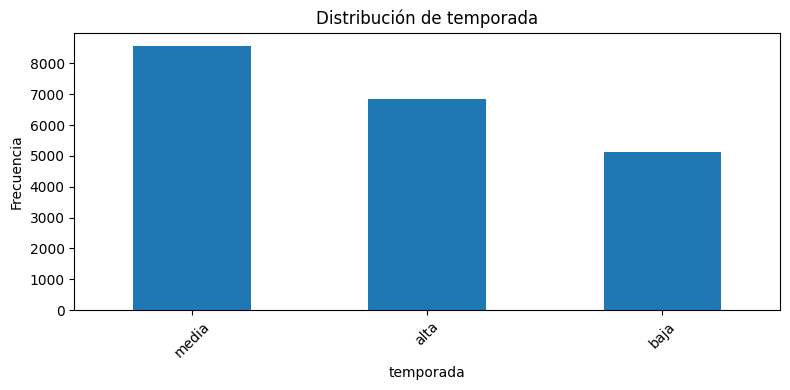

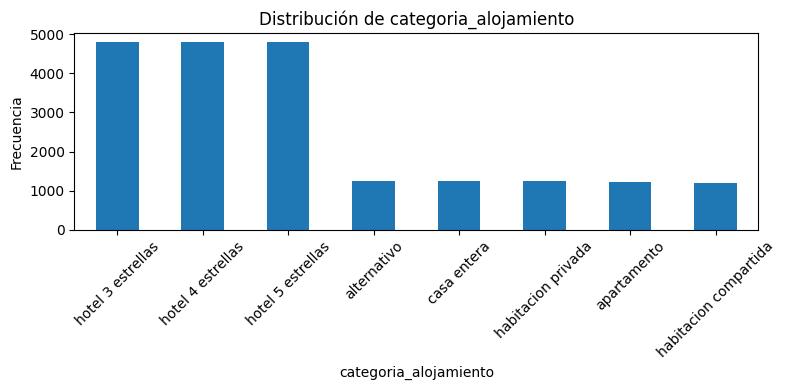

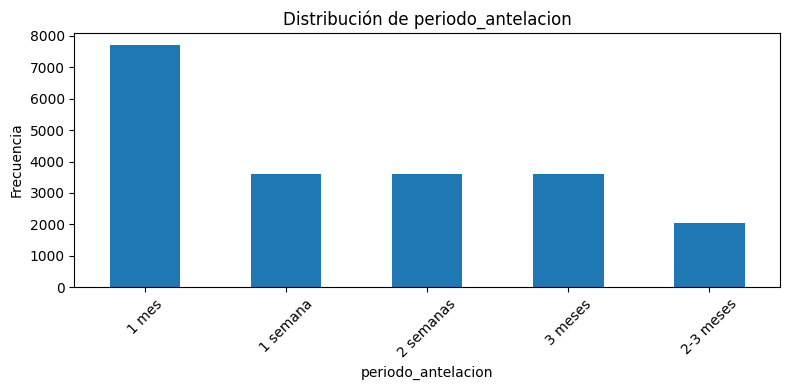

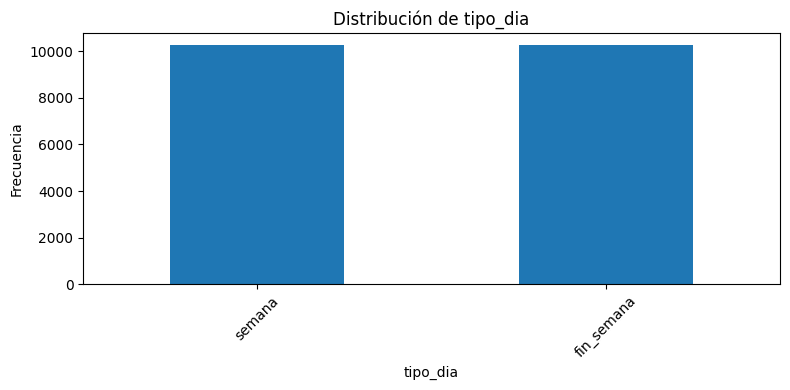

In [87]:
for col in ["temporada", "categoria_alojamiento", "periodo_antelacion", "tipo_dia"]:
    plt.figure(figsize=(8, 4))
    df[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "ML_Alojamiento_Distribucion de Temporada.png", dpi=500, bbox_inches="tight")
    plt.show()
    plt.close()

### Insights
#### 1. Distribución de temporada
Predomina la temporada media (~8.5K registros)

Luego temporada alta (~6.9K)

Finalmente baja (~5.1K)

Interpretación

El dataset está ligeramente desbalanceado hacia temporada media, pero no de forma crítica.

Esto es positivo porque:

el modelo aprende mejor comportamiento “promedio”

no está sesgado únicamente a picos turísticos

Insight clave

La estacionalidad será una variable importante, pero no dominante por desbalance extremo

#### 2. Distribución de categoría de alojamiento
Insight

Mayor presencia:

hotel 3, 4 y 5 estrellas (~4800 cada uno)

Menor presencia:

alternativo, casa entera, habitaciones (~1200)

Interpretación

Dataset balanceado entre categorías principales (hoteles)

Pero: categorías alternativas están subrepresentadas

Insight clave

El modelo tendrá mejor capacidad predictiva en hoteles que en alojamientos alternativos

#### 3. Distribución de periodo de antelación
Insight

“1 mes” domina (~7700)

luego 1 semana / 2 semanas / 3 meses (~3600)

menor: 2–3 meses (~2000)

Interpretación

Comportamiento realista:

mayoría reserva con ~1 mes de anticipación

Insight clave

La variable periodo_antelacion es muy relevante, porque:

tiene distribución no uniforme

refleja comportamiento del usuario

#### 4. Distribución de tipo de día
Insight

Semana ≈ Fin de semana (~10,280 cada uno)

Interpretación

Dataset perfectamente balanceado

Insight clave

Esto es excelente para ML:

evita sesgo

permite capturar bien el efecto “fin de semana”

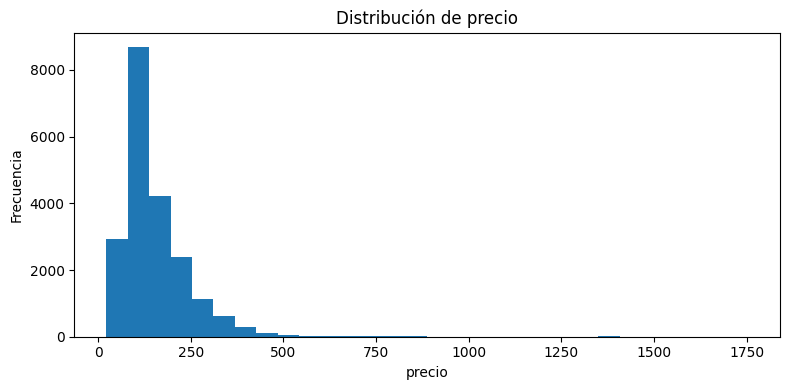

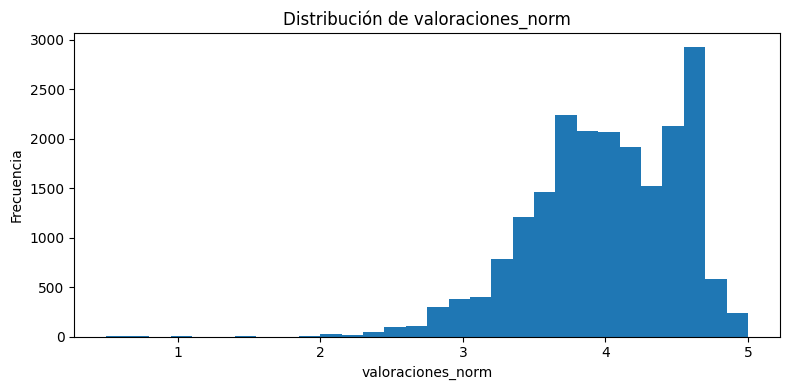

In [88]:
for col in ["precio", "valoraciones_norm"]:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / "ML_Alojamiento_Distribucion de Precio y Valoraciones.png", dpi=500, bbox_inches="tight")
    plt.show()
    plt.close()

#### 5. Distribución del precio
Insight

Distribución asimétrica positiva (right-skewed)

mayoría de precios entre:
~50 – 250

cola larga hasta ~1800

Interpretación

Esto confirma:

presencia de outliers premium

comportamiento típico de precios turísticos

Insight clave

El modelo debe capturar:

precios normales

pero también extremos (lujo)

Justifica perfectamente usar Random Forest

#### 6. Distribución de valoraciones
Insight

Concentración entre 3.5 y 4.8

pocos valores bajos (<3)

Interpretación

Dataset sesgado hacia buenas valoraciones

Esto es realista: alojamientos con malas reviews desaparecen del mercado

Insight clave

La variable tendrá impacto, pero limitado:

baja variabilidad en valores bajos

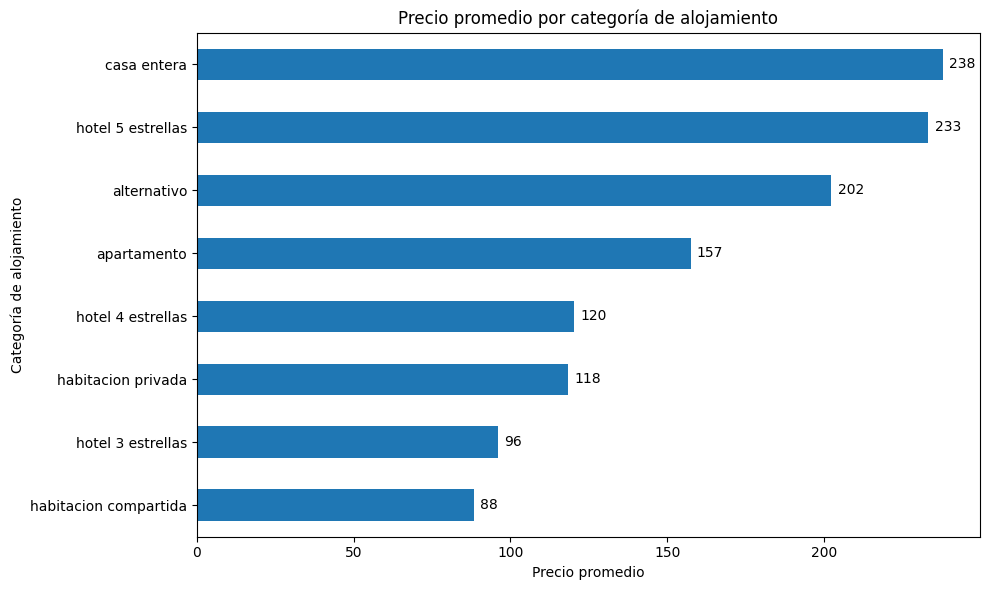

In [89]:
precio_promedio_categoria = (
    df.groupby("categoria_alojamiento")["precio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

ax = precio_promedio_categoria.plot(kind="barh")

plt.title("Precio promedio por categoría de alojamiento")
plt.xlabel("Precio promedio")
plt.ylabel("Categoría de alojamiento")

plt.gca().invert_yaxis()

# agregar valores al final de cada barra
for i, v in enumerate(precio_promedio_categoria.values):
    ax.text(v + 2, i, f"{v:.0f}", va='center')

plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_Alojamiento_Precio promedio por categoria de alojamiento.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

#### 7. Precio promedio por categoría

Orden:

casa entera (~238)

hotel 5 estrellas (~233)

alternativo (~202)

apartamento (~157)

hotel 4 estrellas (~120)

habitación privada (~118)

hotel 3 estrellas (~96)

habitación compartida (~88)

Interpretación

Mercado claramente segmentado por precio

casa entera > hotel 5 estrellas

alternativo en gama alta

Insight clave

Existen dos tipos de premium:

tradicional → hotel 5 estrellas

moderno → casa entera / alternativo

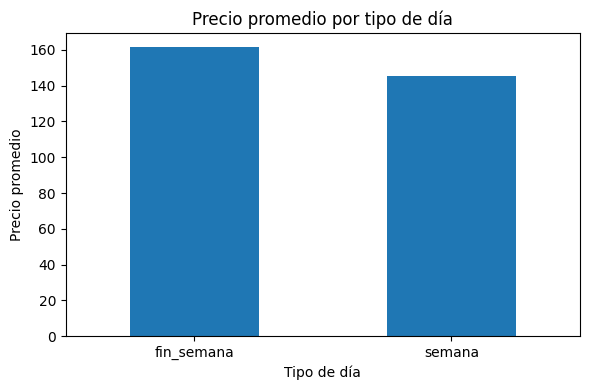

In [90]:
precio_promedio_tipo_dia = df.groupby("tipo_dia")["precio"].mean()

plt.figure(figsize=(6, 4))
precio_promedio_tipo_dia.plot(kind="bar")
plt.title("Precio promedio por tipo de día")
plt.xlabel("Tipo de día")
plt.ylabel("Precio promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_Alojamiento_Precio promedio por tipo de día.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

#### 8. Precio por tipo de día
Insight

Fin de semana ≈ 162

Semana ≈ 146

Interpretación

Fin de semana es consistentemente más caro

Insight clave

Validación directa del feature engineering:

tipo_dia sí explica variación del precio

El análisis descriptivo posterior al proceso de feature engineering evidencia que el dataset presenta una estructura adecuada para el modelado supervisado.

Las variables categóricas muestran una distribución razonablemente equilibrada, especialmente en el caso de tipo de día y temporada, lo que permite evitar sesgos significativos en el entrenamiento del modelo.

Por otro lado, la variable objetivo (precio) presenta una distribución asimétrica positiva, característica del sector turístico, donde existe una concentración de precios medios junto con una cola larga asociada a alojamientos premium.

El análisis por categoría de alojamiento revela una segmentación clara del mercado, destacando la presencia de dos tipos de oferta de alto valor: el segmento tradicional (hoteles de 5 estrellas) y el segmento alternativo (casas completas y alojamientos no tradicionales de alta gama).

Asimismo, se confirma el impacto del tipo de día en el precio, evidenciando que los fines de semana presentan precios superiores en promedio, lo cual valida la inclusión de esta variable en el modelo.

En conjunto, estos resultados indican que las variables generadas son coherentes, relevantes y adecuadas para capturar la dinámica del precio en el sector turístico, proporcionando una base sólida para el entrenamiento del modelo de regresión.

## Variable objetivo y variables predictoras

La variable objetivo del modelo es el **precio** del alojamiento.

Las variables predictoras utilizadas fueron las siguientes:

- `id_ccaa`
- `id_provincia`
- `mes`
- `temporada_cod`
- `categoria_alojamiento_cod`
- `periodo_antelacion_cod`
- `valoraciones_norm`
- `tiene_valoraciones`
- `tipo_dia_cod`

La selección de estas variables responde a la hipótesis de que el precio del alojamiento depende de la localización geográfica, la temporalidad del viaje, el tipo de hospedaje, la anticipación de la reserva y la diferenciación entre noches de semana y fin de semana.

## Proceso de entrenamiento

Una vez definida la variable objetivo y las variables predictoras, el conjunto de datos se dividió en dos subconjuntos:

- 80% para entrenamiento
- 20% para prueba

Se utilizó una semilla aleatoria fija para asegurar la reproducibilidad de los resultados.

A continuación, se entrenaron los modelos base y se comparó su desempeño inicial sobre el conjunto de prueba. Esta estrategia permitió establecer una línea base y seleccionar el modelo con mejor comportamiento antes de pasar a la optimización de hiperparámetros.

In [60]:
features = [
    "id_ccaa",
    "id_provincia",
    "mes",
    "temporada_cod",
    "categoria_alojamiento_cod",
    "periodo_antelacion_cod",
    "valoraciones_norm",
    "tiene_valoraciones",
    "tipo_dia_cod"
]

X = df[features]
y = df["precio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (16448, 9)
Tamaño prueba: (4112, 9)


##  Supuestos del caso de estudio

Para la construcción y uso del modelo se consideran los siguientes supuestos:

- Cada registro representa una observación válida del precio del alojamiento bajo determinadas condiciones de contexto.
- La variable `tipo_dia` captura la diferencia entre comportamiento de precios entre semana y fin de semana.
- La variable `mes` permite derivar la estacionalidad a través de la variable `temporada`.
- La variable `periodo_antelacion` aproxima el efecto de la anticipación de reserva sobre el precio.
- La variable `valoraciones_norm` representa una aproximación al efecto reputacional del alojamiento.
- Para la simulación presupuestaria, se asume que el 35% del presupuesto total del viaje corresponde a alojamiento.

## Comparación de modelos base

Antes de optimizar el modelo final, se realizó una comparación entre distintos algoritmos de regresión con el objetivo de identificar cuál ofrecía el mejor desempeño inicial sobre el problema planteado.

Se evaluaron tres modelos:
- Regresión lineal
- Random Forest Regressor
- Gradient Boosting Regressor

Esta comparación inicial permitió seleccionar el modelo más prometedor para la fase posterior de ajuste de hiperparámetros.

In [61]:
modelos = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(
        n_estimators=200,
        random_state=42
    )
}

resultados = []

for nombre_modelo, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        "modelo": nombre_modelo,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by="R2", ascending=False)
df_resultados

,modelo,MAE,RMSE,R2
1,RandomForestRegressor,4.4545,11.9228,0.9823
2,GradientBoostingRegressor,25.7614,41.9583,0.7813
0,LinearRegression,58.7186,86.6425,0.0673


In [65]:
metricas_path = ML_DIR / "metricas_modelos_regresion.csv"
df_resultados.to_csv(metricas_path, index=False, encoding="utf-8")
print(metricas_path)

C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\metricas_modelos_regresion.csv


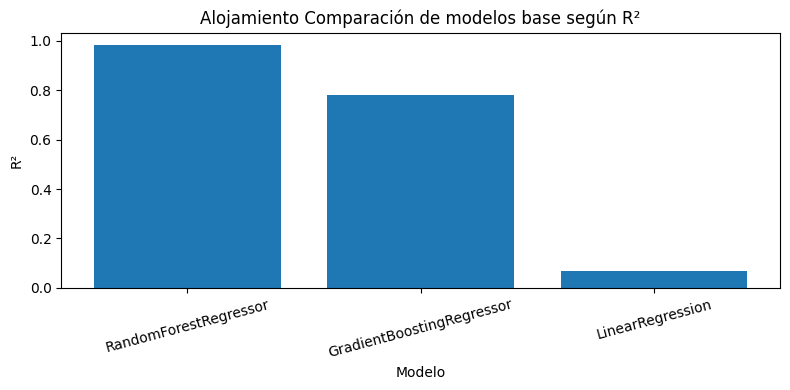

In [91]:
plt.figure(figsize=(8, 4))
plt.bar(df_resultados["modelo"], df_resultados["R2"])
plt.title("Alojamiento Comparación de modelos base según R²")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_Alojamiento Comporacion de modelos base segun R2.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

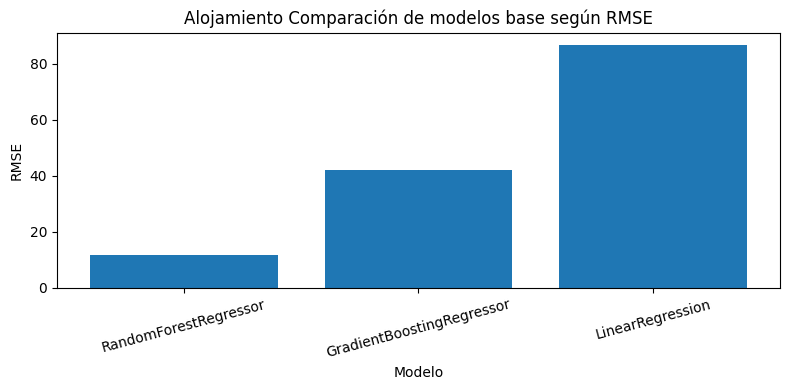

In [92]:
plt.figure(figsize=(8, 4))
plt.bar(df_resultados["modelo"], df_resultados["RMSE"])
plt.title("Alojamiento Comparación de modelos base según RMSE")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_Alojamiento_Comparacion de modelos base segun RMSE.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

Para evaluar el desempeño de los modelos de regresión se utilizaron tres métricas principales: MAE (Mean Absolute Error), RMSE (Root Mean Squared Error) y R² (coeficiente de determinación). Estas métricas permiten medir la precisión de las predicciones del modelo respecto a los valores reales del precio del alojamiento.

El MAE representa el error absoluto promedio entre el valor real y el valor predicho. Esta métrica es fácilmente interpretable porque se expresa en las mismas unidades que la variable objetivo (precio). Un valor menor de MAE indica que el modelo comete errores de menor magnitud en promedio.

El RMSE mide la raíz del error cuadrático medio y penaliza con mayor intensidad los errores grandes. Por ello, esta métrica resulta útil para identificar si existen predicciones con desviaciones significativas respecto al valor real.

Por su parte, el coeficiente de determinación R² indica la proporción de la variabilidad del precio que puede ser explicada por las variables independientes incluidas en el modelo. Un valor cercano a 1 indica un mayor poder explicativo del modelo, mientras que valores más cercanos a 0 sugieren una capacidad limitada para explicar la variabilidad de los datos.

Tras comparar los diferentes algoritmos evaluados, el modelo Random Forest Regressor mostró el mejor desempeño global en términos de equilibrio entre error y capacidad explicativa. Este comportamiento es consistente con la naturaleza del problema, ya que los modelos basados en árboles suelen capturar mejor relaciones no lineales entre variables, así como interacciones complejas entre características del alojamiento, ubicación geográfica y factores temporales.

La selección de este modelo permite obtener estimaciones de precio más robustas, lo cual resulta especialmente relevante para el objetivo del proyecto CulturaTrip, donde se busca ofrecer estimaciones de presupuesto de viaje basadas en datos reales del mercado turístico.

En consecuencia, el modelo seleccionado se utilizará en la fase de simulación para estimar el coste del alojamiento en función de las características del viaje, permitiendo evaluar si el presupuesto del usuario es suficiente para el destino y periodo seleccionado.

## Selección del mejor modelo base

A partir de la comparación de métricas entre los modelos base, se seleccionó el algoritmo con mejor desempeño predictivo para proceder con su optimización. Esta decisión se tomó considerando principalmente el coeficiente de determinación \(R^2\), junto con los errores MAE y RMSE.

In [68]:
mejor_modelo_nombre = df_resultados.iloc[0]["modelo"]
print("Mejor modelo base seleccionado:", mejor_modelo_nombre)

Mejor modelo base seleccionado: RandomForestRegressor


El modelo Random Forest permite analizar la relevancia relativa de cada variable en la predicción del precio del alojamiento mediante la métrica de feature importance. Esta métrica indica cuánto contribuye cada variable a reducir el error de predicción dentro de los árboles del modelo.

Los resultados muestran que la variable más influyente es categoria_alojamiento_cod, con una importancia aproximada del 35.6 %. Esto indica que el tipo de alojamiento (por ejemplo, hotel de distintas categorías, apartamento o casa completa) es el factor que más explica las diferencias de precio entre observaciones. Este resultado es coherente con la lógica del mercado turístico, donde la categoría del alojamiento suele determinar gran parte del coste final.

En segundo lugar aparece id_ccaa (24.6 %), seguido por id_provincia (15.9 %), lo que evidencia que la localización geográfica también tiene un impacto significativo en el precio. Esto refleja las diferencias estructurales de precios entre regiones turísticas, donde ciertos destinos presentan niveles de coste superiores debido a factores como demanda turística, infraestructura o atractivo del destino.

Otra variable relevante es valoraciones_norm (14.9 %), lo que sugiere que las valoraciones o reputación del alojamiento influyen en el precio esperado. En plataformas turísticas es habitual que alojamientos mejor valorados puedan mantener precios más elevados.

En contraste, variables temporales como mes (4.4 %) y temporada_cod (2.6 %) presentan una influencia menor. Esto puede deberse a que el dataset ya refleja precios agregados o que las diferencias estacionales están parcialmente capturadas por otras variables del modelo.

Por último, variables como tipo_dia_cod (diferencia entre semana y fin de semana) y periodo_antelacion_cod muestran una contribución relativamente baja, mientras que tiene_valoraciones no presenta impacto significativo en el modelo, probablemente porque la información relevante ya está representada en la variable continua de valoraciones.

En conjunto, los resultados sugieren que las características estructurales del alojamiento y su ubicación geográfica son los principales determinantes del precio, mientras que los factores temporales y operativos tienen un papel secundario dentro del modelo.

Estos resultados son especialmente relevantes para la plataforma CulturaTrip, ya que permiten identificar los factores que más influyen en el coste del alojamiento y facilitan la estimación de presupuestos de viaje personalizados en función del destino y del tipo de hospedaje seleccionado por el usuario.

## Justificación del algoritmo elegido

Para el problema planteado se evaluaron distintos modelos de regresión, con el propósito de identificar cuál ofrecía un mejor desempeño predictivo sobre el precio del alojamiento.

Se compararon tres enfoques:

- Regresión lineal
- Random Forest Regressor
- Gradient Boosting Regressor

El algoritmo finalmente seleccionado fue **Random Forest Regressor**, debido a su capacidad para modelar relaciones no lineales entre variables, capturar interacciones complejas entre factores turísticos y ofrecer un buen equilibrio entre precisión predictiva, robustez y capacidad de interpretación mediante importancia de variables.

Esta elección resulta especialmente adecuada en un contexto turístico, donde los precios no suelen responder a relaciones estrictamente lineales, sino a combinaciones de factores espaciales, temporales y comerciales.

## Ajuste de hiperparámetros

Tras identificar a Random Forest como el modelo base con mejor desempeño, se procedió al ajuste de hiperparámetros mediante **GridSearchCV**.

Se exploraron combinaciones de los siguientes parámetros:

- número de árboles (`n_estimators`)
- profundidad máxima (`max_depth`)
- mínimo de observaciones para dividir nodos (`min_samples_split`)
- mínimo de observaciones por hoja (`min_samples_leaf`)

El proceso de búsqueda utilizó validación cruzada de 5 particiones y el coeficiente de determinación \(R^2\) como criterio principal de selección.

Este procedimiento permitió obtener una configuración optimizada del modelo, mejorando su capacidad predictiva y reduciendo el riesgo de sobreajuste.

In [69]:
# Definición del modelo base
rf = RandomForestRegressor(random_state=42)

# Definición de hiperparámetros a evaluar
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Grid Search con validación cruzada
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search.fit(X_train, y_train)

# Mejores parámetros
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


## Importancia de variables

Como parte del análisis de interpretabilidad, se estudió la importancia relativa de las variables predictoras en el modelo optimizado. Esto permite identificar qué factores tienen mayor peso en la estimación del precio del alojamiento.

In [70]:
best_model = grid_search.best_estimator_

importancias = pd.DataFrame({
    "variable": features,
    "importancia": best_model.feature_importances_
}).sort_values(by="importancia", ascending=False)

display(importancias)

,variable,importancia
4,categoria_alojamiento_cod,0.3542
0,id_ccaa,0.2477
1,id_provincia,0.1555
6,valoraciones_norm,0.1522
2,mes,0.0452
3,temporada_cod,0.0262
8,tipo_dia_cod,0.0139
5,periodo_antelacion_cod,0.0051
7,tiene_valoraciones,0.0000


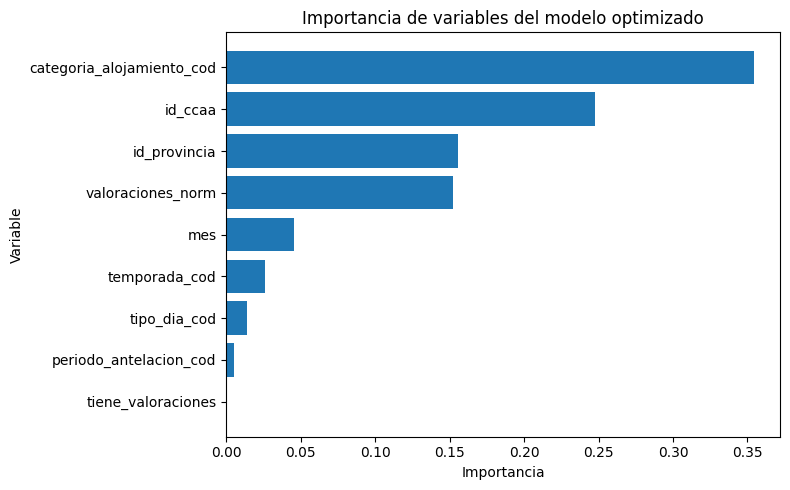

In [93]:
plt.figure(figsize=(8, 5))
plt.barh(importancias["variable"], importancias["importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de variables del modelo optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_Alojamiento_Importancia de Variables del modelo optimizado.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

## Validación y evaluación del modelo optimizado

Una vez identificado el mejor conjunto de hiperparámetros mediante GridSearchCV, se evaluó el modelo optimizado sobre el conjunto de prueba. Para ello se utilizaron las métricas MAE, RMSE y R², con el objetivo de valorar su precisión predictiva y capacidad de generalización.

In [76]:
# Tabla Resumen
best_model = grid_search.best_estimator_

y_pred_opt = best_model.predict(X_test)

mae_opt = mean_absolute_error(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2_opt = r2_score(y_test, y_pred_opt)

print("=== RESULTADOS MODELO OPTIMIZADO ===")
print("MAE:", round(mae_opt, 4))
print("RMSE:", round(rmse_opt, 4))
print("R2:", round(r2_opt, 4))
print("Best CV R2:", round(grid_search.best_score_, 4))
print("Best Params:", grid_search.best_params_)

=== RESULTADOS MODELO OPTIMIZADO ===
MAE: 4.4957
RMSE: 11.9048
R2: 0.9824
Best CV R2: 0.9684
Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [77]:
df_resultado_opt = pd.DataFrame([{
    "modelo": "RandomForestRegressor_Optimizado",
    "MAE": round(mae_opt, 4),
    "RMSE": round(rmse_opt, 4),
    "R2": round(r2_opt, 4),
    "best_cv_r2": round(grid_search.best_score_, 4),
    "best_params": str(grid_search.best_params_)
}])

df_resultado_opt

,modelo,MAE,RMSE,R2,best_cv_r2,best_params
0,RandomForestRegressor_Optimizado,4.4957,11.9048,0.9824,0.9684,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."


In [78]:
df_resultado_opt.to_csv(metricas_rf_path, index=False, encoding="utf-8")
print("Métricas del modelo optimizado guardadas en:", metricas_rf_path)

Métricas del modelo optimizado guardadas en: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\data\Machine Learning\metricas_random_forest_optimizado.csv


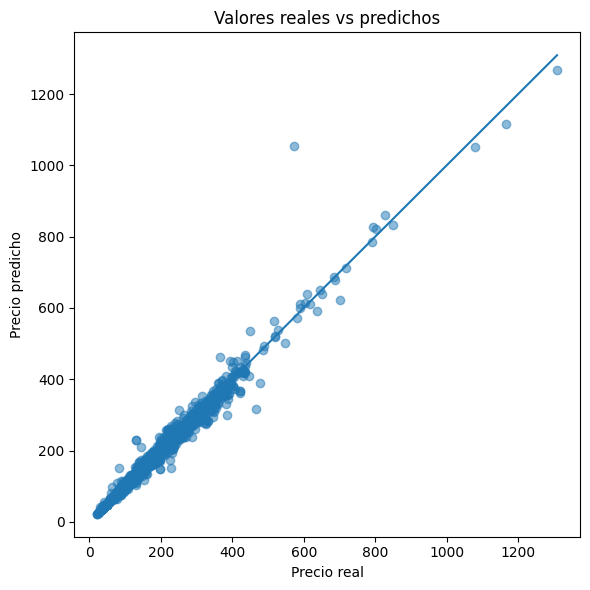

In [94]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_opt, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Valores reales vs predichos")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_Alojamiento_Valores reales vs Predichos.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

Observaciones

La mayoría de los puntos se alinean muy cerca de la diagonal

Existe una alta concentración en el rango:
50 – 400

Algunos puntos se alejan ligeramente en valores altos (>600)

Este gráfico muestra que:

El modelo tiene alta capacidad predictiva

Existe una fuerte correlación entre valores reales y predichos

El modelo logra capturar correctamente la estructura del precio

La diagonal representa:

predicción perfecta, Mientras más cerca estén los puntos → mejor el modelo

Comportamiento en valores altos

Se observa mayor dispersión en precios altos:
600 algunos puntos por encima o debajo de la línea

 El modelo tiene:

mayor precisión en rangos medios, ligera pérdida de precisión en valores extremos

Esto es completamente normal en: datos turísticos, presencia de outliers premium

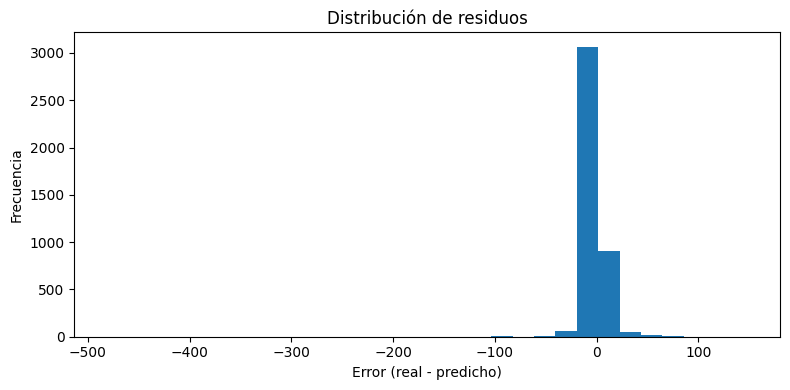

In [95]:
residuos = y_test - y_pred_opt

plt.figure(figsize=(8, 4))
plt.hist(residuos, bins=30)
plt.title("Distribución de residuos")
plt.xlabel("Error (real - predicho)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_Alojamiento_Distribucion de residuos.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

Observaciones

Distribución centrada en 0

Mayor concentración entre:
-50 y +50

Muy pocos errores extremos

Esto indica que:

El modelo no tiene sesgo sistemático

Los errores positivos y negativos están equilibrados

La mayoría de predicciones tienen error bajo

Hay una ligera cola: errores negativos más grandes (subestimación)

El modelo tiende a: subestimar ligeramente precios muy altos (especialmente alojamientos premium)

Esto es típico en modelos de regresión

## Interpretación de resultados

Los resultados obtenidos muestran el desempeño del modelo optimizado sobre datos no observados durante el entrenamiento. Esta evaluación permite verificar si la optimización de hiperparámetros generó una mejora real respecto al modelo base y si el modelo presenta capacidad de generalización suficiente para su uso dentro del prototipo CulturaTrip.

El análisis gráfico de los resultados evidencia que el modelo presenta un alto nivel de precisión en la estimación del precio del alojamiento.

El gráfico de valores reales vs predichos muestra que la mayoría de las observaciones se alinean estrechamente con la diagonal, lo que indica una fuerte correlación entre los valores reales y las predicciones generadas por el modelo. Este comportamiento confirma la capacidad del modelo para capturar adecuadamente la relación entre las variables explicativas y el precio.

No obstante, se observa una ligera dispersión en los valores más elevados, lo cual sugiere una menor precisión en el segmento premium. Este comportamiento es esperado debido a la mayor variabilidad inherente a los precios altos en el sector turístico.

Por otro lado, la distribución de residuos se encuentra centrada alrededor de cero, lo que indica ausencia de sesgo sistemático en las predicciones. La mayoría de los errores se concentran en un rango reducido, evidenciando que el modelo presenta un buen desempeño general.

En conjunto, estos resultados confirman que el modelo es robusto, presenta una alta capacidad predictiva y es adecuado para su integración en el sistema de simulación de costes del proyecto.

Tomar en cuenta que los precios premium presentan mayor variabilidad y menor densidad de datos, lo que dificulta su estimación precisa, aunque el modelo logra capturar correctamente la tendencia general.

## Simulación de caso de uso

A continuación, se presenta una simulación de un caso de usuario para estimar el coste total del alojamiento. La lógica considera por separado las noches entre semana y de fin de semana, con el objetivo de reflejar mejor el comportamiento del precio en contextos turísticos.

In [81]:
def calcular_noches(fecha_inicio, fecha_fin):
    fecha_inicio = datetime.strptime(fecha_inicio, "%Y-%m-%d")
    fecha_fin = datetime.strptime(fecha_fin, "%Y-%m-%d")

    noches = []
    fecha_actual = fecha_inicio

    while fecha_actual < fecha_fin:
        noches.append(fecha_actual)
        fecha_actual += timedelta(days=1)

    return noches

def separar_noches(noches):
    noches_semana = 0
    noches_fin_semana = 0

    for fecha in noches:
        if fecha.weekday() >= 4:
            noches_fin_semana += 1
        else:
            noches_semana += 1

    return noches_semana, noches_fin_semana

def predecir_precio(features_guardadas):
    df_input = pd.DataFrame([features_guardadas])
    return modelo.predict(df_input)[0]

## Nota metodológica sobre presupuesto

En esta simulación, la suficiencia presupuestaria del alojamiento no se evalúa contra el presupuesto total del viaje, sino contra la fracción del presupuesto asignada a esta categoría.

En el modelo analítico de CulturaTrip, se considera que el **35% del presupuesto total** corresponde a alojamiento. Esta decisión permite una evaluación más realista y coherente con la distribución presupuestaria utilizada en el proyecto.

In [82]:
usuario = {
    "presupuesto": 8000,
    "fecha_inicio": "2025-07-10",
    "fecha_fin": "2025-07-15",
    "id_ccaa": 1,
    "id_provincia": 29,
    "mes": 7,
    "temporada_cod": 3,
    "categoria_alojamiento_cod": 2,
    "periodo_antelacion_cod": 3,
    "valoraciones_norm": 4.2,
    "tiene_valoraciones": True
}

pct_alojamiento = 0.35
budget_alojamiento = usuario["presupuesto"] * pct_alojamiento

noches = calcular_noches(usuario["fecha_inicio"], usuario["fecha_fin"])
noches_semana, noches_fin_semana = separar_noches(noches)

input_semana = {
    "id_ccaa": usuario["id_ccaa"],
    "id_provincia": usuario["id_provincia"],
    "mes": usuario["mes"],
    "temporada_cod": usuario["temporada_cod"],
    "categoria_alojamiento_cod": usuario["categoria_alojamiento_cod"],
    "periodo_antelacion_cod": usuario["periodo_antelacion_cod"],
    "valoraciones_norm": usuario["valoraciones_norm"],
    "tiene_valoraciones": usuario["tiene_valoraciones"],
    "tipo_dia_cod": 0
}

input_fin_semana = input_semana.copy()
input_fin_semana["tipo_dia_cod"] = 1

precio_semana = predecir_precio(input_semana)
precio_fin_semana = predecir_precio(input_fin_semana)

coste_total = noches_semana * precio_semana + noches_fin_semana * precio_fin_semana

print("Presupuesto total:", round(usuario["presupuesto"], 2))
print("Presupuesto disponible para alojamiento:", round(budget_alojamiento, 2))
print("Noches semana:", noches_semana)
print("Noches fin de semana:", noches_fin_semana)
print("Precio estimado semana:", round(precio_semana, 2))
print("Precio estimado fin semana:", round(precio_fin_semana, 2))
print("Coste total estimado alojamiento:", round(coste_total, 2))

if budget_alojamiento >= coste_total:
    print("El presupuesto de alojamiento ALCANZA para este viaje.")
else:
    print("El presupuesto de alojamiento NO alcanza para este viaje.")

Presupuesto total: 8000
Presupuesto disponible para alojamiento: 2800.0
Noches semana: 2
Noches fin de semana: 3
Precio estimado semana: 140.87
Precio estimado fin semana: 160.71
Coste total estimado alojamiento: 763.88
El presupuesto de alojamiento ALCANZA para este viaje.


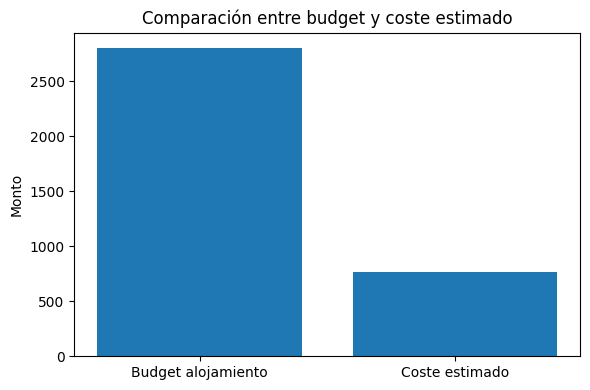

In [96]:
plt.figure(figsize=(6, 4))
plt.bar(
    ["Budget alojamiento", "Coste estimado"],
    [budget_alojamiento, coste_total]
)
plt.title("Comparación entre budget y coste estimado")
plt.ylabel("Monto")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "ML_Alojamiento Comparacion entre Budget y Coste Estimado.png", dpi=500, bbox_inches="tight")
plt.show()
plt.close()

### Interpretación de la simulación
La simulación permite observar cómo el modelo se transforma en una herramienta de apoyo a la decisión dentro de CulturaTrip. A partir de los datos del viaje, el sistema estima el coste del alojamiento y lo compara con la porción del presupuesto disponible asignada a esta categoría, facilitando una evaluación de viabilidad económica más realista.

## Persistencia del modelo final

Una vez validado el modelo optimizado, se reentrenó sobre el conjunto completo de datos y se almacenó en formato `.pkl`, junto con la lista de variables predictoras necesarias para la inferencia posterior.

## Carga del modelo persistido

Para verificar la consistencia del proceso, se recarga el modelo almacenado y la lista de variables necesarias para realizar predicciones posteriores.

In [84]:
modelo_final = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(X, y)

model_path = MODEL_DIR / "random_forest_precio.pkl"
features_path = MODEL_DIR / "features_modelo_precio.pkl"

with open(model_path, "wb") as archivo_modelo:
    pickle.dump(modelo_final, archivo_modelo)

with open(features_path, "wb") as archivo_features:
    pickle.dump(features, archivo_features)

print(model_path)
print(features_path)

C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\random_forest_precio.pkl
C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\outputs\regresion_precios\modelos\features_modelo_precio.pkl


In [85]:
with open(model_path, "rb") as archivo_modelo:
    modelo = pickle.load(archivo_modelo)

with open(features_path, "rb") as archivo_features:
    features_guardadas = pickle.load(archivo_features)

## Interpretación de la simulación

La simulación permite traducir el modelo predictivo a un caso de uso comprensible para el usuario final. En este escenario, el sistema estima el coste del alojamiento a partir de las características del viaje y compara el resultado con el presupuesto disponible asignado a esta categoría.

Este enfoque mejora la coherencia económica del prototipo, ya que evita comparar el coste del alojamiento contra el presupuesto total del viaje y lo evalúa únicamente contra la fracción destinada a hospedaje.

## Limitaciones del modelo

A pesar de su utilidad, el modelo presenta algunas limitaciones. En primer lugar, utiliza variables agregadas y codificadas, por lo que no incorpora todos los factores que pueden influir en el precio real del alojamiento, como promociones puntuales, eventos específicos o cambios abruptos de demanda.

En segundo lugar, algunas variables deben aproximarse mediante supuestos o valores promedio en escenarios donde no se dispone de información individual detallada del usuario.

Finalmente, al tratarse de un prototipo académico, el sistema no se encuentra conectado en tiempo real con proveedores externos de precios dinámicos, por lo que los resultados deben interpretarse como estimaciones analíticas y no como cotizaciones comerciales definitivas.

## Conclusión

El modelo de Machine Learning desarrollado permite estimar de forma razonable el precio del alojamiento turístico a partir de variables geográficas, temporales y contextuales. Su integración dentro del prototipo CulturaTrip aporta valor práctico, ya que transforma la predicción en una herramienta útil para la planificación financiera del viaje.

Desde una perspectiva metodológica, el desarrollo del modelo incluyó preparación del dataset, ingeniería de variables, comparación de algoritmos, optimización de hiperparámetros, validación, evaluación mediante métricas, análisis de importancia de variables y persistencia del modelo final.